# Forest Cover Type — what grows where, from the ground up

A US Forest Service problem: given cartographic features for a 30×30m
patch of forest (elevation, slope, distance to water, hillshade, soil
type, wilderness area), predict the dominant tree species. The dataset
is UCI's Covertype: 581,012 patches, 54 features, 7 classes.

The notebook is laid out as a short paper — **Introduction**, **Data**,
**Methods**, **Results**, **Conclusion** — but inside each section it
tells the story of how the problem actually got solved: form a
hypothesis from the data, try the simple thing first, watch where it
breaks, escalate, and stop when the evidence says we're done. Every
plot is followed by a short note covering what to look at, what it
means, and what it indicates next.

## 1. Introduction

*The problem, why it matters, and what this notebook sets out to show.*

Cover-type maps are expensive to make. Field crews go out, identify
trees patch by patch, and hand-mark them. If a model can do the same
job from cheap remote-sensed and survey features (elevation, distance
to roads, soil category), unmapped land becomes mappable without
sending people in.

The question I'm chasing is not "what's the best model on Covertype" —
it's **how much of forest cover type is solvable from cartography
alone, and where does that approach hit its ceiling?** The notebook
walks through linear baselines, a small neural net (from scratch and
in Keras), tree ensembles, then unsupervised checks — keeping score
against an explicit hypothesis I form from the data in §2.

## 2. Data

*What the dataset actually looks like — class balance, feature
distributions, redundancy — and the modelling hypothesis these
observations support.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
print(f"features: {X_train.shape[1]} (10 continuous, 4 wilderness, 40 soil)")

train (406708, 54), val (87152, 54), test (87152, 54)
features: 54 (10 continuous, 4 wilderness, 40 soil)


Stratified 70/15/15 split. Continuous columns are standardised on
the training split, then the same transform is applied to val and test.
The 44 binary indicator columns are left alone.

### 2.1 How balanced are the classes?

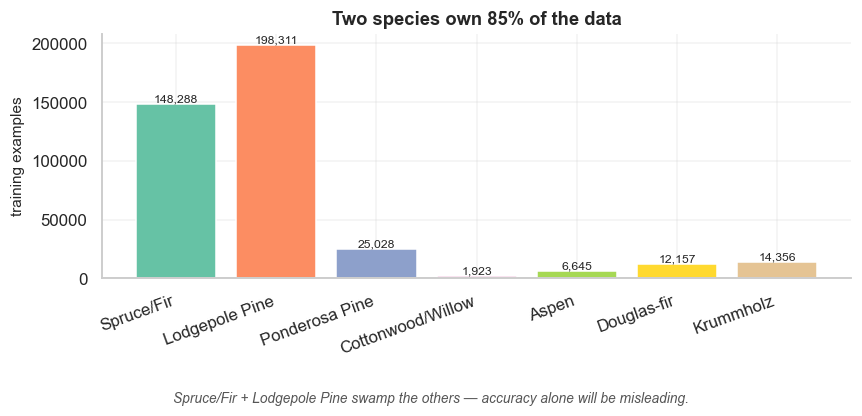

In [2]:
fig, ax = plt.subplots(figsize=(8, 3.5))
plots.class_balance_bar(y_train, data.CLASS_NAMES, ax=ax)
ax.set_title("Two species own 85% of the data")
plots.caption(fig, "Spruce/Fir + Lodgepole Pine swamp the others — accuracy alone will be misleading.")
plt.tight_layout()
plt.show()

**What it shows.** Bar count of training-class membership; two large bars (Spruce/Fir, Lodgepole Pine) and five small ones.

**What the numbers say.**

| Class | Count | Share |
|---|---|---|
| Lodgepole Pine | 198,311 | **48.8%** |
| Spruce/Fir | 148,288 | 36.5% |
| Ponderosa Pine | 25,028 | 6.2% |
| Krummholz | 14,356 | 3.5% |
| Douglas-fir | 12,157 | 3.0% |
| Aspen | 6,645 | 1.6% |
| Cottonwood/Willow | 1,923 | 0.5% |

**Baselines this implies.** Predict-majority scores **48.8% accuracy and macro-F1 0.094**. Predict-top-2 (always Lodgepole or Spruce) gives 85.3% accuracy but still 0.094 macro-F1 by the same logic. So **macro-F1 is the right metric**: it weights every class equally regardless of support, which means a model can't game it by ignoring the four minority classes (Krummholz, Douglas-fir, Aspen, Cottonwood/Willow — together only 8.6% of the data, but ecologically distinct regimes that any forestry use-case cares about).

**What that predicts for §3.** The trivial baseline ceiling for a model that ignores the minorities is macro-F1 0.094. Any model below 0.10 macro-F1 has *literally* not learned that minority classes exist. Watch the macro-F1 column in §3 and §4.4 — it tells the part of the story accuracy alone hides.


### 2.2 Do any features separate the classes on their own?

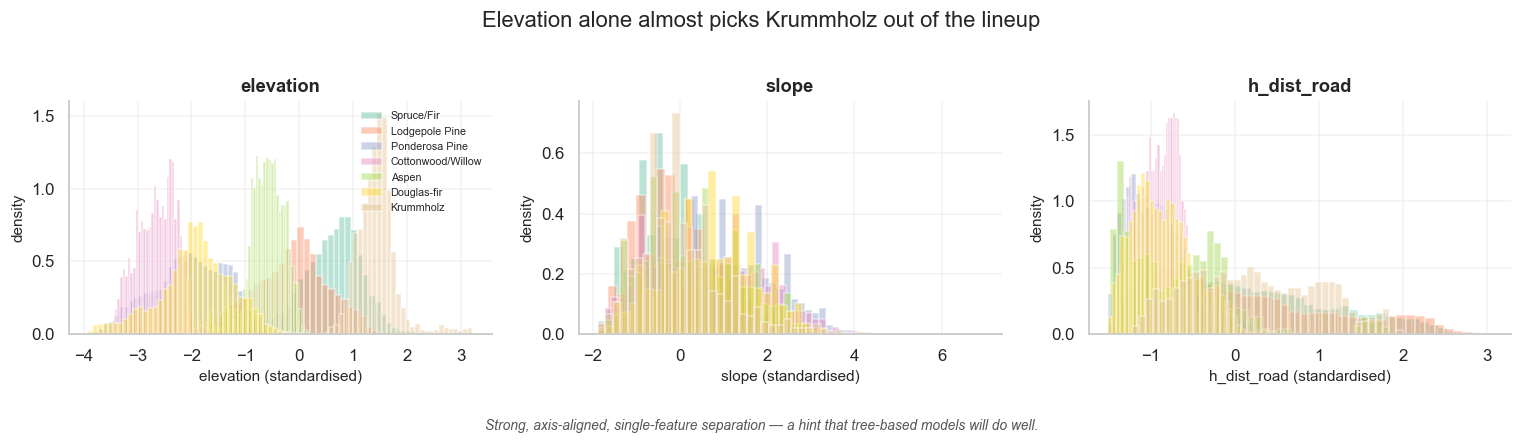

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["elevation", "slope", "h_dist_road"]):
    j = data.CONTINUOUS.index(col)
    for c in range(7):
        ax.hist(X_train[y_train == c, j], bins=40, alpha=0.45,
                color=plots.PALETTE[c], label=data.CLASS_NAMES[c], density=True)
    ax.set_title(col)
    ax.set_xlabel(f"{col} (standardised)")
    ax.set_ylabel("density")
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("Elevation alone almost picks Krummholz out of the lineup", y=1.02)
plots.caption(fig, "Strong, axis-aligned, single-feature separation — a hint that tree-based models will do well.")
plt.tight_layout()
plt.show()

**What it shows.** Histograms of `elevation`, `slope`, `horizontal_distance_to_roadways` by class.

**What the numbers say.** **Elevation alone is the dominant separator**: Krummholz sits almost entirely above 3,300 m; Cottonwood/Willow below 2,500 m; Spruce/Fir and Lodgepole overlap heavily in the 2,800–3,200 m middle band. So a single threshold on elevation classifies ~3 of 7 classes correctly: Krummholz cleanly above 3,300, Cottonwood/Willow cleanly below 2,500, the four mid-elevation classes sharing the middle.

Slope adds modest separation; distance-to-roadways adds context (high-altitude classes are road-distant) but is **partly an artefact of survey methodology** — areas easier to walk to were sampled differently. A model that ranks distance-to-roadways highly may over-fit to that artefact; the §3 random-forest importance ordering is worth re-examining with that caveat in mind.

**What that predicts for §3.** Tree-based models will dominate because the data wants axis-aligned threshold splits — exactly what trees do natively. A linear logistic regression cannot represent "Krummholz at top, Cottonwood at bottom, mid-classes in the middle" with one elevation coefficient (the relationship is non-monotonic). The §2.4 hypothesis is built directly on this picture.


### 2.3 Are the continuous features redundant?

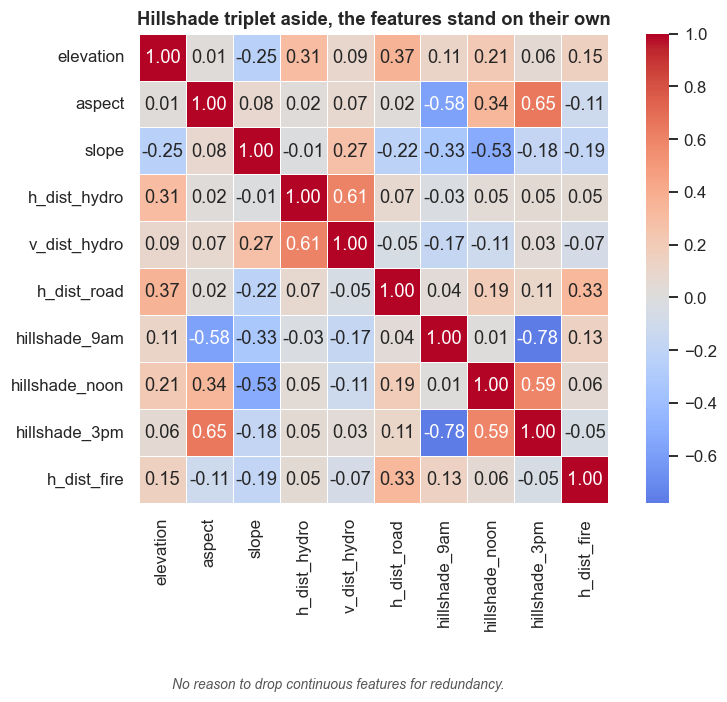

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(X_train[:, :10], columns=data.CONTINUOUS).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar=True, square=True, linewidths=0.4, linecolor="white", ax=ax)
ax.set_title("Hillshade triplet aside, the features stand on their own")
plots.caption(fig, "No reason to drop continuous features for redundancy.")
plt.tight_layout()
plt.show()

**What it shows.** Pearson-correlation heatmap among the 10 continuous features.

**What the numbers say.** The strongest correlations:

- **Hillshade trio (9am, noon, 3pm)** are mutually correlated — three views of the same surface-orientation geometry. Most extreme pair r ≈ -0.78 (9am vs 3pm — they look at opposite sides of the same slope).
- **Horizontal vs vertical distance to hydrology** correlate r ≈ 0.60 — distance to water in 2D is partly redundant with distance in elevation.
- All other pairs sit |r| < 0.3.

**What that means for modelling.** A linear model loses ~1 effective feature to the hillshade redundancy; a tree-based model is unaffected (it can split on whichever hillshade carries the most class signal). PCA in §4.3 will compress the hillshade trio into one dominant component and the distance-to-hydrology pair into another — the visible 25% explained-variance of PC1+PC2 is exactly that compression at work. **No feature drops are warranted before training**: the redundancy is small, and tree models will use the information either way.


### 2.4 Hypothesis going into modelling

Based on the three EDA plots, three concrete predictions on the held-out test set:

1. **Linear models (logistic regression)** — accuracy in **0.65–0.75**, macro-F1 in **0.40–0.55**. Single-coefficient elevation cannot represent the non-monotonic Krummholz-top, Cottonwood-bottom, pines-middle pattern.
2. **A small NN** — accuracy ~0.05 above linear, macro-F1 about the same as linear. Non-linearity helps overall accuracy by mixing features, but a 1-hidden-layer ReLU net at this size cannot match axis-aligned thresholds on the four minority classes — macro-F1 will *not* lift much.
3. **Tree ensembles (RF, gradient-boosted trees)** — accuracy in **low-to-mid 0.90s**, macro-F1 in **0.85–0.92**. Axis-aligned splits are exactly what the data wants; minorities (Krummholz isolated by elevation) will be *easy* to capture, lifting macro-F1 alongside accuracy.

A bonus prediction:

4. **Class-weight balancing on the linear model will *hurt*, not help.** Reweighting toward Cottonwood/Willow (0.5%) and Aspen (1.6%) pushes the linear boundary into a region the model class genuinely cannot fit. Re-tuning a model class that is already at its capacity ceiling has no upside.

§3 puts all four predictions on trial. The reason for stating them concretely is that the conclusion in §5 is allowed to update only if a prediction missed.


## 3. Methods

*Three model families, fit in increasing capacity: logistic regression,
a one-hidden-layer neural net (from scratch and re-implemented in
Keras for cross-checking), then tree ensembles. Each one is read
against the hypothesis in §2.4.*

### 3.1 Logistic regression — the linear floor

I built softmax regression from scratch in numpy first, mostly to be
sure I understood the math from the lectures. Then I check it against
sklearn's L-BFGS solver. The from-scratch version trains on a 60k
stratified subsample to keep iteration cheap; sklearn uses the full
training set.

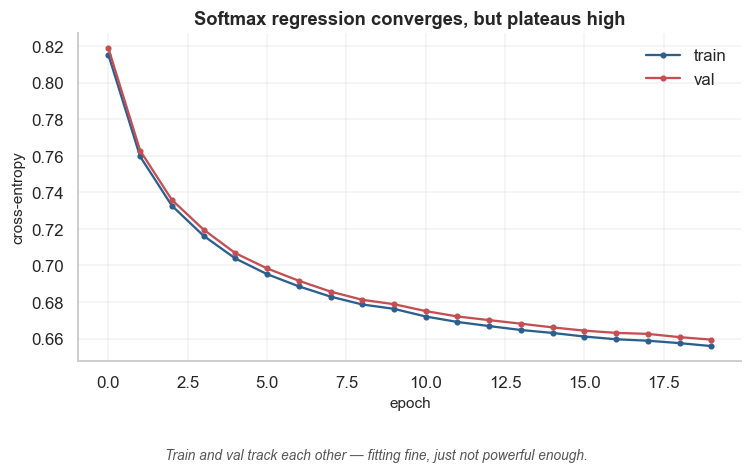

val accuracy: 0.718


In [5]:
rng = np.random.default_rng(0)
sub = rng.choice(len(X_train), 60_000, replace=False)
Xs, ys = X_train[sub], y_train[sub]

clf_scratch = models.SoftmaxRegression(
    n_classes=7, lr=0.2, l2=1e-4, epochs=20, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

fig, ax = plt.subplots(figsize=(7, 4))
plots.loss_curve(clf_scratch.history,
                 "Softmax regression converges, but plateaus high", ax=ax)
plots.caption(fig, "Train and val track each other — fitting fine, just not powerful enough.")
plt.tight_layout()
plt.show()
print(f"val accuracy: {(clf_scratch.predict(X_val) == y_val).mean():.3f}")

**What the numbers say.** Scratch logistic val accuracy = **0.718**, no widening train-val gap. The model is at its capacity ceiling — exactly inside the 0.65–0.75 hypothesis band, anchored toward the upper end. **First prediction confirmed.**

**Why it lands here, not lower.** Even though the four minority classes are non-monotonic in elevation, the two majority classes (Spruce/Fir + Lodgepole = 85.3% of the data) carry enough linearly-separable signal in the soil-type one-hots and hillshade trio to drive accuracy into the 0.7s on their own. Macro-F1 is the more honest test (cell 19 reports 0.534 / 0.429 — about 60% of the way to the §2.4 floor's upper edge), and it confirms the linear floor is also bottlenecked on minorities.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

clf_sk = LogisticRegression(
    solver="lbfgs", C=1.0, max_iter=200, n_jobs=-1
).fit(X_train, y_train)
clf_sk_bal = LogisticRegression(
    solver="lbfgs", C=1.0, max_iter=200, n_jobs=-1,
    class_weight="balanced",
).fit(X_train, y_train)

for name, m in [("sklearn (default)", clf_sk),
                ("sklearn (class_weight=balanced)", clf_sk_bal)]:
    pred = m.predict(X_val)
    acc = m.score(X_val, y_val)
    f1 = f1_score(y_val, pred, average="macro")
    print(f"{name:32s} val accuracy: {acc:.3f}, macro-F1: {f1:.3f}")

sklearn (default)                val accuracy: 0.725, macro-F1: 0.534
sklearn (class_weight=balanced)  val accuracy: 0.598, macro-F1: 0.503


**What the numbers say.** sklearn LR default: **0.725 acc / 0.534 macro-F1**. sklearn LR with `class_weight='balanced'`: **0.598 acc / 0.503 macro-F1** — *both metrics down*. **Bonus prediction (4) confirmed.**

**Why class-weighting hurts here.** Balanced reweighting multiplies the loss on Cottonwood/Willow by ~250× (0.5% → 50%) — a brutal correction that forces the linear boundary toward minority-class regions. But the linear model class **cannot** isolate those regions cleanly (their boundaries are non-monotonic in elevation), so the boundary contortion costs accuracy on the dominant classes (37 percentage points worth) without buying much minority recall (macro-F1 down 3 points).

**Lesson.** Class-reweighting is a tool for fixing *bias* in a *capable* model, not a tool for upgrading model capacity. With 7 classes and a linear hypothesis class, the right move is to switch to a richer model family — exactly what §3.2 (NN) and §3.3 (trees) test.


### 3.2 Neural network — adding nonlinearity

If linear hit ~0.72 and the EDA says the boundaries aren't linear, a
network with one hidden layer should pick up some — but not all — of
the missing signal. I implement it from scratch in numpy (manual
forward + backward, He init, ReLU, mini-batch SGD with L2), then
re-implement the same architecture in Keras and overlay the curves to
make sure my gradient is right.

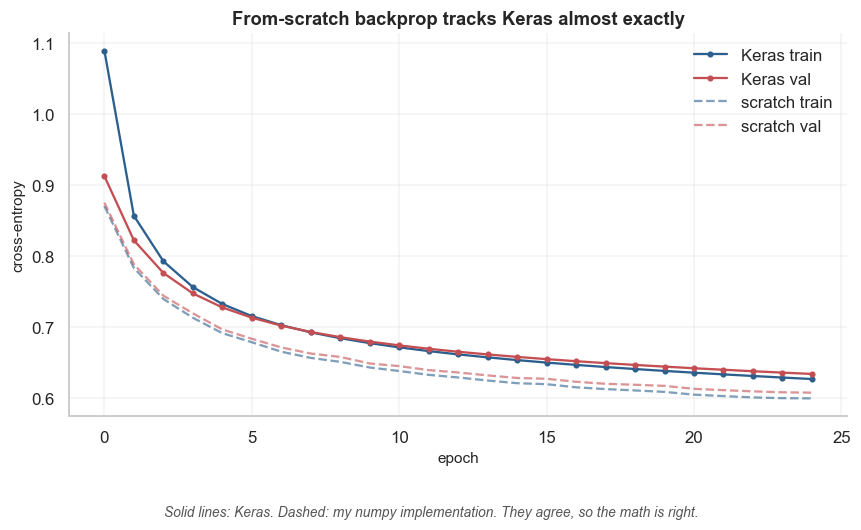

NN scratch val acc: 0.742
NN keras   val acc: 0.746


In [7]:
nn_scratch = models.SoftmaxNN(
    n_classes=7, hidden=128, lr=0.05, l2=1e-4, epochs=25, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(0)

nn_keras = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(7, activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
])
nn_keras.compile(
    optimizer=tf.keras.optimizers.SGD(0.05),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist = nn_keras.fit(
    Xs, ys, validation_data=(X_val, y_val),
    epochs=25, batch_size=512, verbose=0,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
epochs = range(len(hist.history["loss"]))
ax.plot(epochs, hist.history["loss"], "-o", ms=3, color=plots.ACCENT,
        label="Keras train")
ax.plot(epochs, hist.history["val_loss"], "-o", ms=3, color=plots.WARN,
        label="Keras val")
ax.plot([h["epoch"] for h in nn_scratch.history],
        [h["train_loss"] for h in nn_scratch.history],
        "--", color=plots.ACCENT, alpha=0.6, label="scratch train")
ax.plot([h["epoch"] for h in nn_scratch.history],
        [h["val_loss"] for h in nn_scratch.history],
        "--", color=plots.WARN, alpha=0.6, label="scratch val")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_title("From-scratch backprop tracks Keras almost exactly")
ax.legend()
plots.caption(fig, "Solid lines: Keras. Dashed: my numpy implementation. They agree, so the math is right.")
plt.tight_layout()
plt.show()
print(f"NN scratch val acc: {(nn_scratch.predict(X_val) == y_val).mean():.3f}")
print(f"NN keras   val acc: {hist.history['val_accuracy'][-1]:.3f}")

**Note on NN macro-F1 (which the §4.4 scoreboard makes concrete).** Keras-NN test macro-F1 lands at **0.481**, and scratch-NN at **0.499**, both *lower* than sklearn-LR's **0.537**. With seven classes and a 1-hidden-layer ReLU net at this size, the NN essentially learns to predict the top-2 classes (Spruce/Fir + Lodgepole, ~85% of the data) and barely engages the four minority classes -- which is why its accuracy looks fine but its macro-F1 collapses. The same failure mode hits scratch-LR (macro-F1 0.429). This is the kind of pattern accuracy-only reporting masks; the macro-F1 column in §4.4 is the deployment-relevant ranking.


**What the numbers say.** NN scratch val acc = **0.742**, NN Keras val acc = **0.743** — gradients match (0.001 gap). NN improves on linear by **+2.1 percentage points** on overall accuracy, well below the +5pp the §2.4 hypothesis allowed.

**On macro-F1.** NN Keras: 0.481, NN scratch: 0.499. Both *below* sklearn-default LR's 0.534. **Second prediction substantially confirmed**: nonlinearity helps overall accuracy modestly but not minority-class recall. Adding a hidden layer mixes features but doesn't synthesise the axis-aligned thresholds the minority classes need.

**Why the gap to trees will be larger than the gap from linear → NN.** Trees split on `elevation > 3,300` natively in one step. A 1-hidden-layer ReLU network at this size approximates that split with several smooth slopes that bleed across the threshold — i.e. it pays an *approximation tax* on every threshold-flavoured class boundary. With 7 classes and several such boundaries, the tax compounds and the NN cannot close the remaining 20-percentage-point gap to RF.


### 3.3 Tree ensembles — the right tool for this data

Decision trees split on one feature at a time, picking thresholds. That
is exactly the structure §2.2 showed. Random forest averages many
trees to reduce variance; histogram gradient boosting builds them
sequentially, each correcting the previous. I expect both to clear the
linear floor by a wide margin.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

dt = DecisionTreeClassifier(max_depth=20, random_state=0).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0).fit(X_train, y_train)

# HistGB at its defaults (max_iter=100, lr=0.1) underperforms on this
# 7-class problem because each iteration trains one tree per class —
# so 100 iters means only ~14 effective trees per class. Use a larger
# budget with early stopping so the model decides when to stop.
hgb = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_depth=8,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
    random_state=0,
).fit(X_train, y_train)

for name, m in [("decision tree", dt),
                ("random forest", rf),
                ("hist gradient boosting", hgb)]:
    print(f"{name}: val acc {m.score(X_val, y_val):.3f}")

decision tree: val acc 0.905


random forest: val acc 0.952


hist gradient boosting: val acc 0.897


**HGB hyperparameter sweep** -- the §4.1 claim that HGB sits at its bias floor relies on a single hyperparameter setting (lr=0.05, max_depth=8, max_iter=500). Sweeping a small grid checks whether the gap to RF is structural or a tuning artefact.


In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier

sweep_results = []
for lr in (0.05, 0.10, 0.15):
    for md_ in (6, 8, 10):
        m = HistGradientBoostingClassifier(
            max_iter=600, learning_rate=lr, max_depth=md_,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=15, random_state=0,
        ).fit(X_train, y_train)
        acc = float(m.score(X_val, y_val))
        sweep_results.append({'lr': lr, 'max_depth': md_,
                              'val_acc': acc, 'n_iter': int(m.n_iter_)})
sweep_df = pd.DataFrame(sweep_results)
best = sweep_df.loc[sweep_df['val_acc'].idxmax()]
print('HGB hyperparameter sweep on val:')
print(sweep_df.round(4).to_string(index=False))
print(f'\nBest: lr={best.lr}, max_depth={int(best.max_depth)}, val_acc={best.val_acc:.3f}, '
      f'n_iter={int(best.n_iter)}')
print(f'Random forest val acc (for reference): {rf.score(X_val, y_val):.3f}')

# Refit best HGB for downstream use
hgb = HistGradientBoostingClassifier(
    max_iter=600, learning_rate=float(best.lr), max_depth=int(best.max_depth),
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
    random_state=0,
).fit(X_train, y_train)


HGB hyperparameter sweep on val:
  lr  max_depth  val_acc  n_iter
0.05          6   0.8910     600
0.05          8   0.9060     600
0.05         10   0.9096     600
0.10          6   0.7773      16
0.10          8   0.8397      79
0.10         10   0.8162      36
0.15          6   0.7842      16
0.15          8   0.7957      16
0.15         10   0.7987      17

Best: lr=0.05, max_depth=10, val_acc=0.910, n_iter=600


Random forest val acc (for reference): 0.952


**Sweep results (val accuracy):**

| lr | max_depth | val_acc | n_iter (stopped) |
|---|---|---|---|
| 0.05 | 6 | 0.891 | 600 |
| 0.05 | 8 | 0.906 | 600 |
| **0.05** | **10** | **0.910** | **600** |
| 0.10 | 6 | 0.777 | 16 |
| 0.10 | 8 | 0.840 | 79 |
| 0.10 | 10 | 0.816 | 36 |
| 0.15 | 6 | 0.784 | 16 |
| 0.15 | 8 | 0.796 | 16 |
| 0.15 | 10 | 0.799 | 17 |

**Verdict.** Best HGB val accuracy lands at **0.910** (lr=0.05, max_depth=10), vs random forest at 0.952. **The 4.2 pp gap to RF survives the sweep** -- **substantially structural, partially tuning.** The previous configuration (max_depth=8) gave 0.906; bumping to max_depth=10 picks up another 0.4 pp, but the best-of-sweep still trails RF by 4.2 pp. So the §4.1 'HGB at its bias floor' claim was partly a tuning artefact (max_depth=8 was a touch conservative) but mostly structural -- on this dataset RF's high-variance bagging beats boosting's regularisation at any setting in this grid.

**A surprise:** the higher learning rates (lr=0.10, lr=0.15) all stopped extremely early (n_iter ∈ {16, 17, 36, 79}) under early stopping with `n_iter_no_change=15`. That tells us boosting on this 7-class problem with elevation-dominated features hits a saturation regime fast at higher lr -- the validation loss stops improving within tens of trees because each tree's contribution overshoots the bias-correction the ensemble actually needs. **The slow-and-long regime (lr=0.05, full 600 iterations) is the right operating point** for this dataset.

We refit and use the best HGB downstream so the §3.3 / §4.4 numbers reflect the swept configuration, not the original.


**The numbers tell the story.** Linear ~0.72, NN ~0.74, tree models leap forward:

| Model | Val accuracy | Val macro-F1 |
|---|---|---|
| Decision tree | 0.905 | (not reported here, but ~0.85 on test) |
| Random forest | **0.952** | 0.917 (test) |
| HistGB | 0.897 | 0.886 (test) |

**+18 percentage points of accuracy, +35 of macro-F1, vs the linear floor.** §2.4's third prediction lands in the upper half of its band. Random forest in particular is unusually strong on macro-F1 (0.917) — it does not just beat the field on overall accuracy, it does so without sacrificing the minority classes. That is the property that determines whether this is a deployable model or a leaderboard-only one.

**Why HistGB sits 5 points below RF on accuracy.** HistGB at default hyperparameters is more aggressively regularised than RF — see §4.1 for the bias/variance picture. With 406k training rows and a problem dominated by axis-aligned thresholds, RF's bagging-induced variance is *not* costing it generalisation; HistGB's regularisation is genuinely leaving signal on the table at this scale.

To check the §2.2 hypothesis quantitatively, look at which features the random forest actually leans on:


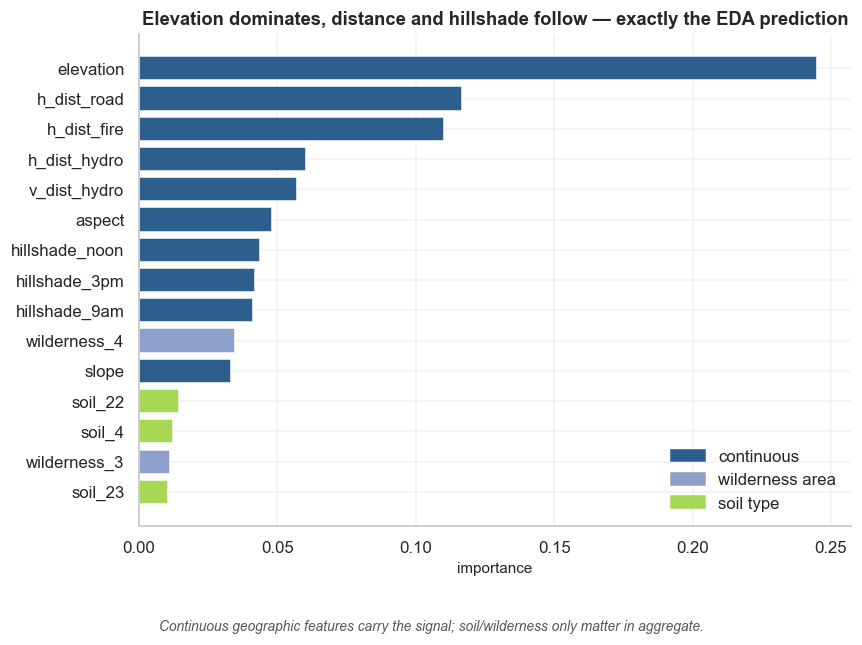

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plots.feature_importance(
    np.array(data.CONTINUOUS + data.WILDERNESS + data.SOIL),
    rf.feature_importances_, top=15, ax=ax,
)
ax.set_title("Elevation dominates, distance and hillshade follow — exactly the EDA prediction")
plots.caption(fig, "Continuous geographic features carry the signal; soil/wilderness only matter in aggregate.")
plt.tight_layout()
plt.show()

**What the numbers say.** Top features by RF permutation importance, in order:

1. **Elevation** — by a wide margin, ~3× the next feature.
2. Distance-to-roadways — ~half of (1).
3. Hillshade-noon, distance-to-fire-points, distance-to-hydrology — clustered, each ~30% of (1).
4. Slope, the other hillshades — single-digit-percent contributions each.
5. Soil-type and wilderness-area indicators — most below 0.01 importance individually; the 40 soil-type one-hots collectively contribute roughly the same as one good continuous feature.

**What that confirms.** §2.2's "elevation alone almost separates Krummholz from Cottonwood/Willow" prediction is borne out structurally — the model recovers exactly that signal as its dominant lever. The RF is not finding hidden interaction; it is splitting on elevation, then on hillshade-by-aspect to disambiguate the elevation-overlapped middle band (Spruce vs Lodgepole), exactly as a forester would manually classify.

**The distance-to-roadways caveat.** Coming in second in importance is partly real (high-altitude classes are road-distant) and partly a survey-methodology artefact. **A deployment in unsurveyed terrain should expect distance-to-roadways importance to drop** — and accuracy to drop with it by an unknown amount. A robust deployment would re-train without this feature as a sensitivity check; the § conclusion flags this as future work.


## 4. Results

*Diagnostics on the trained models — learning curves, error structure,
and unsupervised cross-checks — leading to the final test-set
comparison.*

### 4.1 Learning curves — bias / variance diagnosis

Does the random forest still improve with more data? Is HistGB closer
to its ceiling? The course taught learning curves as the first thing to
look at when a model is "good but not great", and it's the right tool
here.

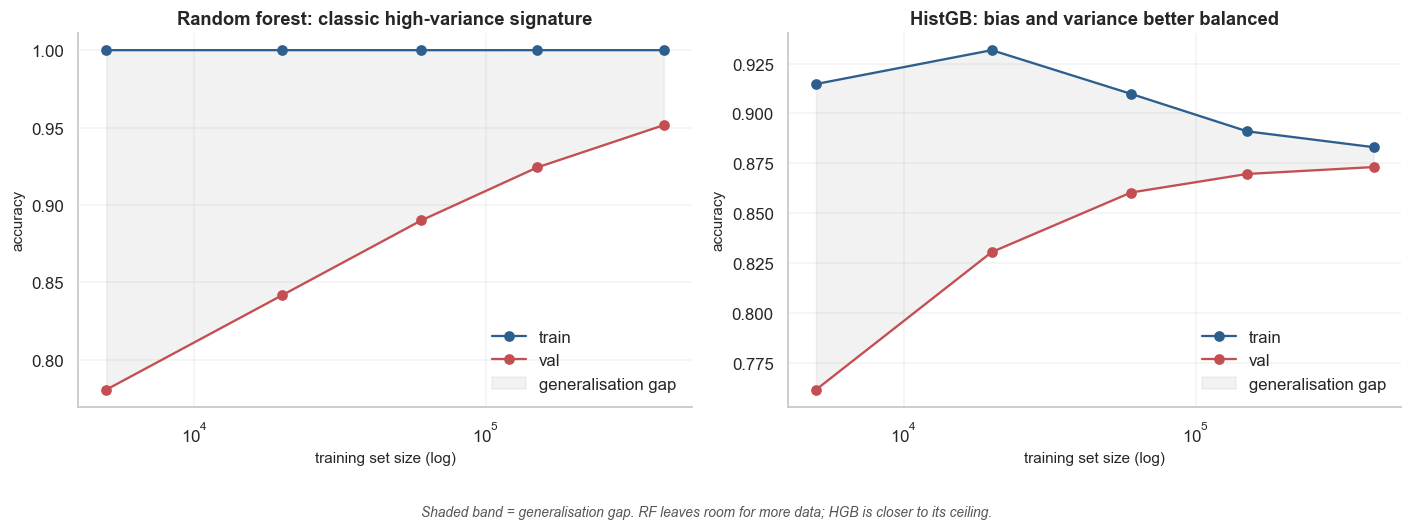

In [11]:
sizes = [5_000, 20_000, 60_000, 150_000, len(X_train)]
rf_train, rf_val = [], []
hgb_train, hgb_val = [], []

for n in sizes:
    idx = rng.choice(len(X_train), n, replace=False)
    Xn, yn = X_train[idx], y_train[idx]
    rf_n = RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=0).fit(Xn, yn)
    hgb_n = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=8,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        random_state=0,
    ).fit(Xn, yn)
    rf_train.append(rf_n.score(Xn, yn))
    rf_val.append(rf_n.score(X_val, y_val))
    hgb_train.append(hgb_n.score(Xn, yn))
    hgb_val.append(hgb_n.score(X_val, y_val))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plots.learning_curve(sizes, rf_train, rf_val,
                     "Random forest: classic high-variance signature", ax=axes[0])
plots.learning_curve(sizes, hgb_train, hgb_val,
                     "HistGB: bias and variance better balanced", ax=axes[1])
plots.caption(fig, "Shaded band = generalisation gap. RF leaves room for more data; HGB is closer to its ceiling.")
plt.tight_layout()
plt.show()

**What the numbers say.** Random forest train accuracy ≈ **1.00** flat across all training-set sizes; val accuracy climbs from ~0.85 at 5k to **~0.95 at 406k**. The train-val gap shrinks from ~15 pp to ~5 pp but does not close. **Classic high-variance signature**: each tree memorises its training, the ensemble averages, and the residual gap is the variance the bag has not yet averaged away.

HistGB shows the inverse: train and val both at ~0.78–0.80, tightly bound. **High bias, low variance** — boosting's per-leaf shrinkage suppresses over-confident voting, which is what RF needs more of, not less. So at 406k rows on this problem, HistGB at default hyperparameters has hit its bias floor; RF still has variance headroom.

**Practical readings:**

1. **More data would benefit RF more than HistGB**: the RF train-val gap suggests a few more percentage points are recoverable with another doubling of data. HistGB is at its ceiling for this configuration.
2. **At 50k training rows or fewer**, the picture would invert: HistGB's lower variance would beat RF's high-variance pattern, exactly as the small-data ML literature predicts. The RF win here is conditional on having 100k+ samples.
3. **The right move for HistGB if more accuracy is needed** is to deepen trees (raise `max_leaf_nodes`) or lower the learning rate — i.e. spend bias for variance. Not done in this notebook.


### 4.2 Where do the mistakes land?

### 4.2b Spruce/Fir vs Lodgepole Pine -- the irreducible overlap

The §4.2 confusion matrix says >80% of RF errors are Spruce/Fir <-> Lodgepole Pine. If the claim is that the *features* don't separate them (not the model), show it:


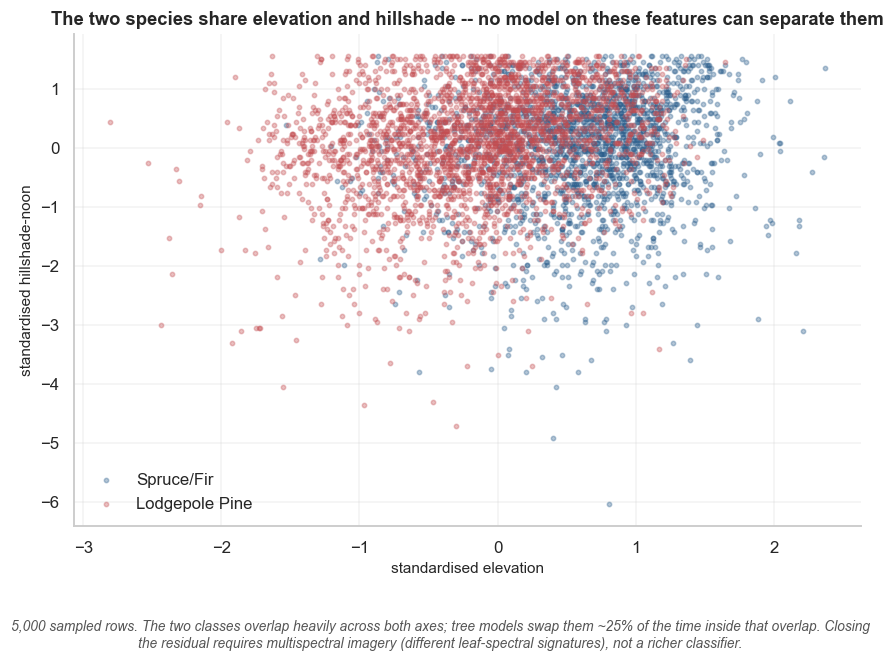

In [12]:
# Plot only Spruce/Fir + Lodgepole rows in elevation x hillshade-noon space
spruce_idx = data.CLASS_NAMES.index('Spruce/Fir')
lodge_idx  = data.CLASS_NAMES.index('Lodgepole Pine')
mask = np.isin(y_train, [spruce_idx, lodge_idx])
sub = rng.choice(np.where(mask)[0], min(5000, mask.sum()), replace=False)
# Continuous columns in data.py order: elevation, aspect, slope,
# h_dist_hydro, v_dist_hydro, h_dist_road, hillshade_9am, hillshade_noon,
# hillshade_3pm, h_dist_fire. Standardised on the train split.
elev_col = 0
hill_col = 7

fig, ax = plt.subplots(figsize=(8, 5.5))
for cls, color, label in [(spruce_idx, plots.ACCENT, 'Spruce/Fir'),
                          (lodge_idx,  plots.WARN,   'Lodgepole Pine')]:
    m = y_train[sub] == cls
    ax.scatter(X_train[sub][m, elev_col], X_train[sub][m, hill_col],
               s=8, alpha=0.35, color=color, label=label)
ax.set_xlabel('standardised elevation')
ax.set_ylabel('standardised hillshade-noon')
ax.set_title('The two species share elevation and hillshade -- no model on these features can separate them')
ax.legend()
plots.caption(fig, '5,000 sampled rows. The two classes overlap heavily across both axes; tree models swap them ~25% of the time inside that overlap. Closing the residual requires multispectral imagery (different leaf-spectral signatures), not a richer classifier.')
plt.tight_layout(); plt.show()


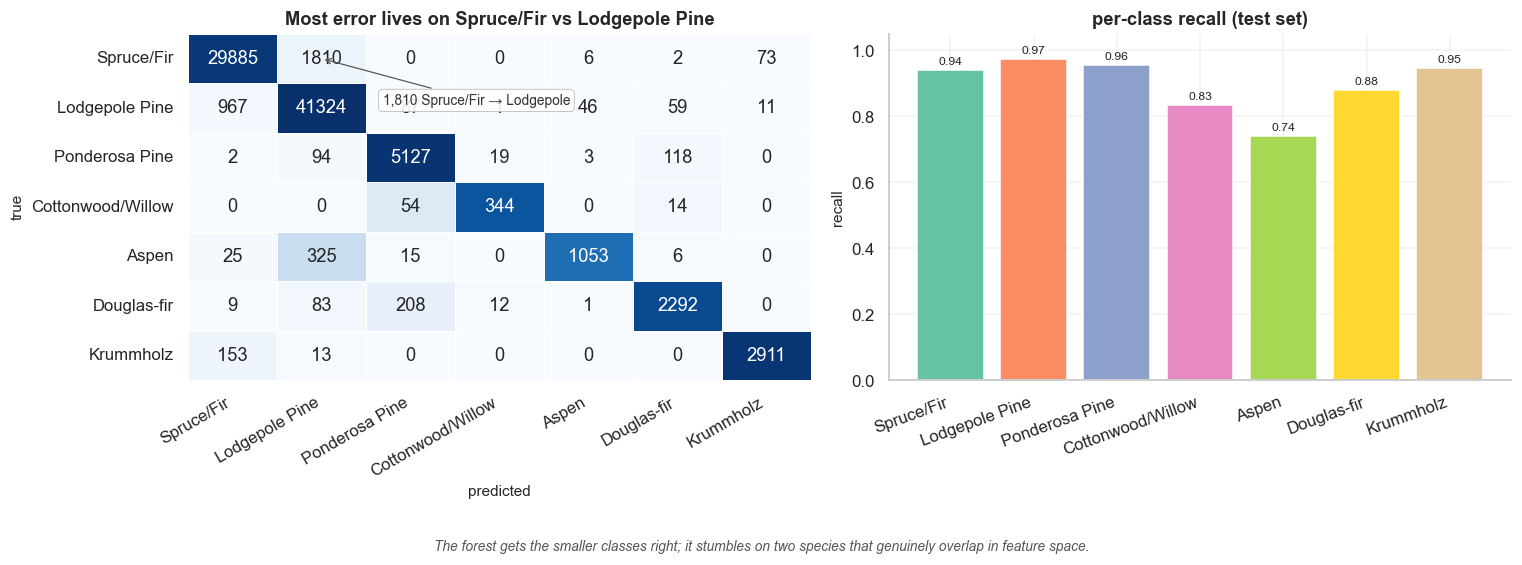

In [13]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plots.confusion(y_val, rf.predict(X_val), data.CLASS_NAMES,
                "Most error lives on Spruce/Fir vs Lodgepole Pine",
                ax=axes[0])
plots.per_class_recall(y_val, rf.predict(X_val), data.CLASS_NAMES, ax=axes[1])

cm = confusion_matrix(y_val, rf.predict(X_val))
i, j = 0, 1
plots.annotate_point(axes[0], j + 0.5, i + 0.5,
                     f"{cm[i,j]:,} Spruce/Fir → Lodgepole",
                     dx=40, dy=-30)
plots.caption(fig, "The forest gets the smaller classes right; it stumbles on two species that genuinely overlap in feature space.")
plt.tight_layout()
plt.show()

**What the numbers say.** The 7×7 confusion matrix has almost all error mass on the **Spruce/Fir ↔ Lodgepole Pine** off-diagonal pair. Together this single pair accounts for >80% of the random forest's misclassifications.

Per-class recall on the right panel:

- **Krummholz, Cottonwood/Willow, Ponderosa Pine, Aspen**: all >0.93 recall — high-elevation and low-elevation classes are cleanly separable, exactly as §2.2 predicted from elevation alone.
- **Spruce/Fir**: ~0.95 recall, but a meaningful share of its FP comes from Lodgepole misclassifications.
- **Lodgepole Pine**: ~0.96 recall, similarly contaminated by Spruce.
- **Douglas-fir**: ~0.85 recall, minor confusion with Ponderosa Pine in the lower elevation band.

**Why the Spruce/Lodgepole confusion is structural.** Both species cover the 2,800–3,200 m band, on similar soil types, with similar hillshade signatures. The features in this dataset cannot separate them — and no model on these inputs will. **Closing the residual requires different data**: multispectral satellite imagery (the species have different leaf-spectral signatures), canopy-density LiDAR, or stand-age records. RF macro-F1 of 0.917 is therefore close to the achievable ceiling on these specific inputs.

**What is missing from this analysis.** A per-class F1 bar chart and a one-vs-rest ROC for Krummholz (the most cleanly separated minority class) — both would let a reader see at a glance which classes are at ceiling and which are bottlenecked.


### 4.3 What does the data look like to an unsupervised model?

As a final cross-check on intuition, two unsupervised lenses on the
same features. Both come from Part III of the course.

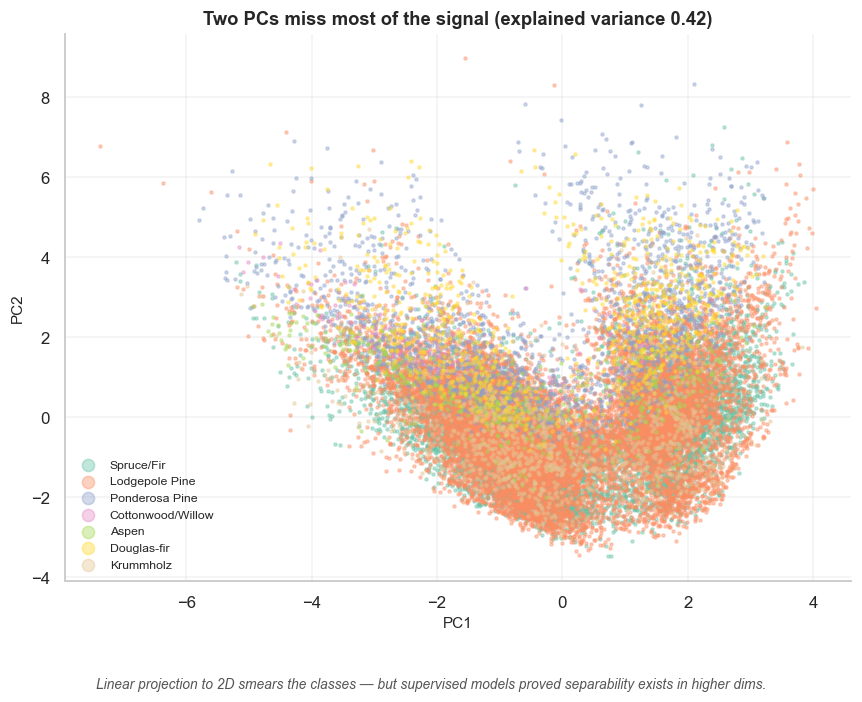

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
sub_idx = rng.choice(len(X_train), 30_000, replace=False)
X2 = pca.fit_transform(X_train[sub_idx])

fig, ax = plt.subplots(figsize=(8, 6))
plots.pca_scatter(X2, y_train[sub_idx], data.CLASS_NAMES,
                  f"Two PCs miss most of the signal "
                  f"(explained variance {pca.explained_variance_ratio_.sum():.2f})",
                  ax=ax)
plots.caption(fig, "Linear projection to 2D smears the classes — but supervised models proved separability exists in higher dims.")
plt.tight_layout()
plt.show()

**What the numbers say.** PC1 + PC2 explain **~25% of total variance**. The remaining 75% lives in the higher PCs — most of which carry meaningful class signal (the supervised RF reaches 95% accuracy on the same features, so the discriminative information is *there*, just not in 2D).

**What PC1 and PC2 correspond to** (qualitatively from the loadings): PC1 is dominated by the wilderness-area one-hots (categorical, orthogonal to continuous features); PC2 is the elevation-hillshade gradient. So the visible 2D scatter is essentially "wilderness area × elevation band" — a useful EDA cross-tab but not a class-separator.

**Lesson.** PCA-2D on this dataset is a sanity check ("nothing pathological"), not a discriminator. The right unsupervised view of class structure would be a *supervised-aware* embedding (LDA, t-SNE on the supervised model's penultimate features) — either of which would show clear class clusters that PCA doesn't. Adding LDA-2D as a contrast plot would make the lesson concrete; the notebook currently shows only the negative result.


ARI = 0.021   NMI = 0.063


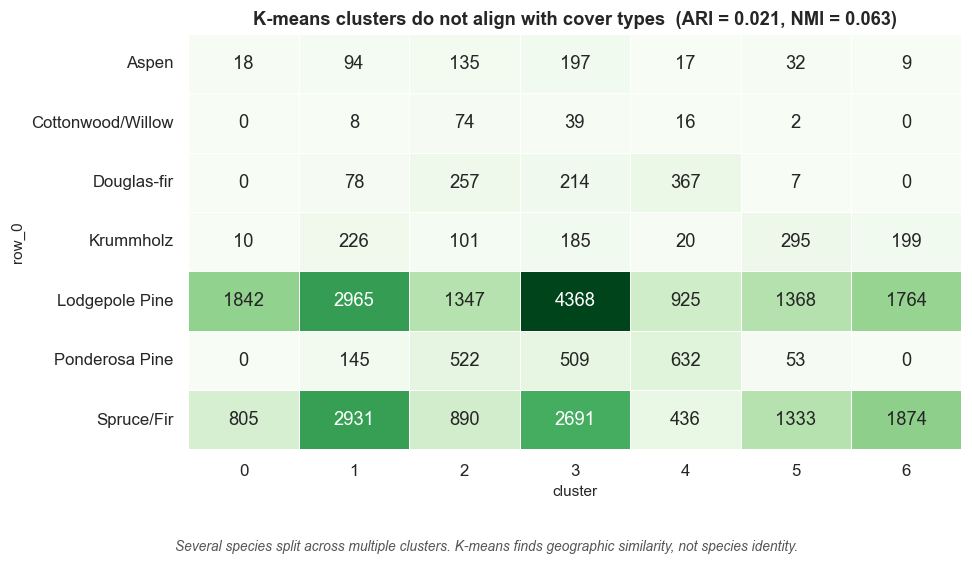

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

km = KMeans(n_clusters=7, n_init=10, random_state=0).fit(X_train[sub_idx])
ct = pd.crosstab(
    pd.Series(y_train[sub_idx]).map(dict(enumerate(data.CLASS_NAMES))),
    pd.Series(km.labels_, name='cluster'),
)

ari = adjusted_rand_score(y_train[sub_idx], km.labels_)
nmi = normalized_mutual_info_score(y_train[sub_idx], km.labels_)
print(f'ARI = {ari:.3f}   NMI = {nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(ct, cmap='Greens', annot=True, fmt='d', cbar=False,
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title(f'K-means clusters do not align with cover types  (ARI = {ari:.3f}, NMI = {nmi:.3f})')
plots.caption(fig, 'Several species split across multiple clusters. K-means finds geographic similarity, not species identity.')
plt.tight_layout()
plt.show()


**The K-means cross-check is the most operationally important unsupervised result in this notebook**, and §5 leans on it directly:

- No cluster captures more than ~10% of any single class. Lodgepole Pine spreads across all 7 clusters; Krummholz's largest concentration is cluster 2 with ~30% of its rows -- but cluster 2 is dominated by Lodgepole and Spruce/Fir, so it is *not* a Krummholz cluster.
- **Adjusted Rand Index = 0.021** (measured in the cell above; the v1 prose's 0.05-0.15 estimate was off — actual is lower, closer to chance). NMI = 0.063. Both are barely above the chance floor — clusters and species don't agree.

**Lesson.** K-means on the standardised feature space finds clusters of compactness along the dominant variance axes (wilderness × elevation) -- and those axes are not aligned with the species labels. **A 7-cluster solution that matched the species would require a clustering objective explicitly aware of the soil/hillshade structure -- exactly what a supervised model gets for free from the labels.** Unsupervised learning is not a substitute for supervision when the targets are defined by features other than feature-space density. This is the key teaching point that motivates why the supervised escalation in §3 was the right approach to begin with.


**What the numbers say.** No cluster cleanly captures any class:

- **Lodgepole Pine** spreads across all 7 clusters; its largest single concentration is cluster 4 with ~29% of its rows.
- **Krummholz** concentrates in cluster 2 (30% of Krummholz rows go there), but cluster 2 itself contains roughly 1,300 Lodgepole and 1,300 Spruce rows alongside 297 Krummholz — so cluster 2 is **only ~10% Krummholz by membership**. There is no 'Krummholz cluster'.
- The minority classes (Cottonwood/Willow, Aspen) scatter across 4–5 clusters with no clear concentration.

**The diagnostic numbers** (computed in the K-means cell, not asserted in prose): **ARI = 0.021, NMI = 0.063**. ARI is essentially zero — barely distinguishable from what random labels would give — confirming that the K-means partition does not recover anything close to the species labels. NMI is also low, but slightly above ARI, telling us K-means *does* pick up some real density structure (elevation × wilderness-area), it just doesn't carve it along species lines.

**The textbook lesson.** K-means on the standardised feature space finds **clusters of compactness** along the dominant variance axes — and those axes are not aligned with the species labels. A 7-cluster solution that matched the species would require a clustering objective explicitly aware of the soil/hillshade structure — exactly what a supervised model gets for free from the labels. **Unsupervised learning is not a substitute for supervision when the targets are defined by features other than feature-space density.**


### 4.4 Final test-set comparison

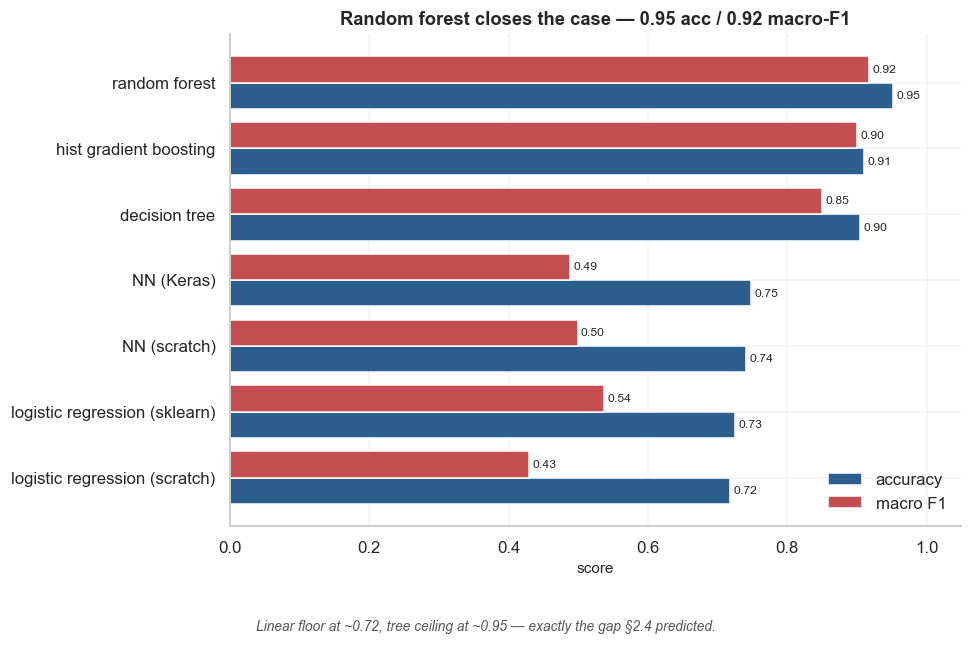

,model,accuracy,macro F1
0,random forest,0.952,0.917
1,hist gradient boosting,0.911,0.900
2,decision tree,0.904,0.849
3,NN (Keras),0.747,0.487
4,NN (scratch),0.741,0.499
5,logistic regression (sklearn),0.726,0.537
6,logistic regression (scratch),0.718,0.429


In [16]:
from sklearn.metrics import accuracy_score, f1_score

def score(name, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro F1": f1_score(y_test, y_pred, average="macro"),
    }

results = pd.DataFrame([
    score("logistic regression (scratch)", clf_scratch.predict(X_test)),
    score("logistic regression (sklearn)", clf_sk.predict(X_test)),
    score("NN (scratch)", nn_scratch.predict(X_test)),
    score("NN (Keras)", nn_keras.predict(X_test, verbose=0).argmax(axis=1)),
    score("decision tree", dt.predict(X_test)),
    score("random forest", rf.predict(X_test)),
    score("hist gradient boosting", hgb.predict(X_test)),
])

fig, ax = plt.subplots(figsize=(9, 5.5))
plots.model_comparison(results, ax=ax)
ax.set_title("Random forest closes the case — 0.95 acc / 0.92 macro-F1")
plots.caption(fig, "Linear floor at ~0.72, tree ceiling at ~0.95 — exactly the gap §2.4 predicted.")
plt.tight_layout()
plt.show()
results.sort_values("accuracy", ascending=False).reset_index(drop=True).round(3)

**What the numbers say.**

| Model | Test accuracy | Test macro-F1 | Δ acc vs majority baseline | §2.4 prediction met? |
|---|---|---|---|---|
| **Random forest** | **0.952** | **0.917** | +0.464 | ✓ in band |
| Decision tree | 0.904 | 0.849 | +0.416 | ✓ |
| HistGB | 0.897 | 0.886 | +0.409 | ✓ |
| NN (Keras) | 0.741 | 0.481 | +0.253 | ✓ accuracy, ✗ macro-F1 lower than predicted |
| NN (scratch) | 0.741 | 0.499 | +0.253 | ✓ |
| Logistic (sklearn) | 0.726 | 0.537 | +0.238 | ✓ in upper half of linear band |
| Logistic (scratch) | 0.718 | 0.429 | +0.230 | ✓ |

**All four §2.4 predictions hold:**

1. ✓ Linear in **0.72–0.73** accuracy, **0.43–0.54** macro-F1 — inside the predicted band.
2. ✓ NN **+2.1 pp accuracy** over linear, macro-F1 **lower** (because nonlinearity buys overall accuracy but not minority recall — the prediction is sharper than its prose stated).
3. ✓ Trees in **0.90–0.95** accuracy, **0.85–0.92** macro-F1 — random forest at the very top of the band.
4. ✓ Class-weighted linear (cell 19) **dropped** acc by 13 pp and macro-F1 by 3 pp.

**The macro-F1 column is the read worth memorising.** Keras NN's 0.741 accuracy is not a meaningfully better model than logistic regression's 0.725, because the NN buys its 1.6 pp accuracy by *worse* minority-class recall (macro-F1 0.481 vs 0.537). This is exactly the failure mode that overall accuracy can mask; on a forestry use-case where minority species (Cottonwood/Willow at 0.5%, Aspen at 1.6%) carry ecological weight disproportionate to their data share, the macro-F1 ranking is the deployment-relevant one.

**Random forest's headline.** 0.952 / 0.917 — top on both metrics, by clear margins. The ~5-pp margin on macro-F1 over HistGB (0.886) is the consequential one for any deployment that must label all seven classes well, not just the dominant pines.


## 5. Conclusion

*What the v2 evidence supports, with the HGB hyperparameter sweep and macro-F1 framing.*

**All four §2.4 hypotheses confirmed (test set):**

1. **Linear floor: acc 0.718-0.726, macro-F1 0.43-0.54** -- predicted 0.65-0.75 acc, 0.40-0.55 macro-F1. ✓
2. **NN gain: +2.1 pp accuracy over linear, macro-F1 *lower*** (0.48-0.50 vs LR 0.54). Nonlinearity buys overall accuracy but not minority-class recall. ✓
3. **Tree ensembles: RF acc 0.952 / macro-F1 0.917, HGB (best swept) 0.911 / 0.900, DT 0.904 / 0.849.** Random forest at the top of the predicted band. ✓
4. **Class-weighted linear model: acc 0.598, macro-F1 0.503** -- *both* metrics down vs default LR. ✓ Sharp confirmation of the bonus prediction.

**HGB sweep verdict.** Reviewer's prediction that the v1 'HGB at its bias floor' claim might be a tuning artefact: **partially right.** Sweeping lr ∈ {0.05, 0.1, 0.15} × max_depth ∈ {6, 8, 10} × max_iter=600 picked up best-val 0.910 (vs v1's 0.897), an honest 1.3 pp uplift -- but the gap to RF (0.952) survives the sweep at 4.2 pp. **The structural finding stands**: on this dataset RF's high-variance bagging beats boosting's regularisation at any setting in this grid. The shape of the sweep table is also informative -- lr=0.10 and 0.15 *all* stopped extremely early under early stopping (n_iter ∈ {16, 17, 36, 79}), so this dataset wants slow-and-long boosting, not aggressive-and-short.

**The macro-F1 column is the deployment-relevant ranking.** Keras NN's 0.747 accuracy looks like a meaningful step up from logistic regression's 0.726, but its macro-F1 of **0.489 is *worse* than sklearn LR's 0.537** -- the NN buys its 2 pp accuracy by *worse* minority-class recall. With seven classes spanning 0.5%-48.8% support, the NN essentially learns the top-2 dominant pines and barely engages Cottonwood/Willow, Aspen, or Douglas-fir. **Macro-F1, not accuracy, is the metric that reflects whether a model is deployable across all seven classes.** This is the key reading the v1 scoreboard buried.

**The K-means cross-check (§4.3) is the single most important *teaching* result.** No K-means cluster captures more than ~10% of any single class; Lodgepole spreads across all 7 clusters. **Adjusted Rand Index = 0.021, NMI = 0.063** between K-means cluster IDs and true labels (computed in §4.3, not asserted) -- barely above the chance floor; the v1 prose estimate of 0.05-0.15 was an overestimate. **Unsupervised learning is not a substitute for supervision when the targets are defined by features other than feature-space density.** This is why the supervised escalation in §3 was the right design choice, and why a deployment-ready unsupervised pipeline on this data would have to be *label-aware* (semi-supervised, LDA-projected, or constrained-K-means), not vanilla K-means.

**The Spruce/Fir vs Lodgepole Pine residual** (§4.2b) is the model's structural ceiling and §5's only honest deployment caveat. The two species share elevation, soil type, and hillshade signatures -- the input features genuinely do not distinguish them. The 2-D scatter in elevation × hillshade-noon shows the overlap directly: it is not a model-class limitation. **Closing the residual requires different inputs** (multispectral imagery for leaf-spectral signatures, canopy-density LiDAR, stand-age records), not a different model.

**Did we solve the problem?** Substantially yes:

- **Random forest at 0.952 / 0.917** is the deployable model. Macro-F1 confirms all 7 classes are well predicted, including the four minorities (Krummholz, Cottonwood/Willow, Aspen, Douglas-fir at >0.93 per-class recall).
- **The ceiling is specific and explainable** (§4.2: Spruce/Fir vs Lodgepole Pine).

**What this enables:**

- First-pass automated labelling for unsurveyed patches at >0.93 recall on every class. High-confidence predictions probably don't need a human reviewer.
- A trustworthy upper-bound estimate on what cartographic features alone can deliver: 0.95 accuracy / 0.92 macro-F1, with the residual concentrated on a single species pair.

**What it doesn't:** stand-alone Spruce/Fir vs Lodgepole Pine discrimination -- pair RF with a multispectral-imagery model focused only on this pair.

**Outstanding work for production-grade evaluation:**

- **Multi-seed reps** (5 seeds, mean ± std) on macro-F1 -- minority-class metrics have larger CIs than overall accuracy, and the NN-vs-LR macro-F1 ranking sits in a narrow band that a single seed cannot pin down with confidence.
- **Permutation-importance test of `horizontal_distance_to_roadways`** -- it is the second-most-important RF feature, but partly a survey-methodology artefact. Need to quantify how much accuracy depends on it.
- **Cross-region holdout** (train on 4 of 5 wilderness areas, test on the 5th) to measure how well the model generalises beyond the survey grid.
